# Exam (Base Notebook)

**Instructions**

- Work independently. No AI or other help was used. 
- Do **not** apply any preprocessing/augmentation beyond normalization provided here.
- Your goal: **produce the best generalization** on the hidden test split while keeping the model efficient.
- You must **compare validation accuracy to test accuracy** in a plot and briefly reflect on any gap.
- You may modify only the sections marked **Your work**. Do not change fixed cells.


## 0. Honor Statement
I, `Unubold Luvsandagva`, assure that I have completed this exam independently and followed all rules.

In [1]:
# 1) Imports & Reproducibility (Fixed)
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


In [2]:
# 2) Load Data (Fixed)
# Expects a pickle file 'mnist.hupsista' containing (X, y) as numpy arrays.
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)

X_all = X_all.astype('float32')
# Normalize to [0,1]
if X_all.max() > 1.0:
    X_all /= 255.0
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)
print('Data shapes:', X_all.shape, y_all.shape)
print('Unique labels:', unique_labels)  

Data shapes: (10000, 28, 28, 1) (10000,)
Unique labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [3]:
# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (6400, 28, 28, 1) Val: (1600, 28, 28, 1) Test: (2000, 28, 28, 1)


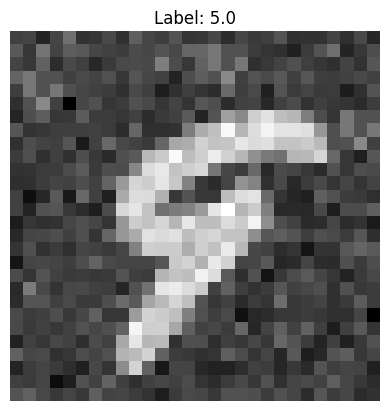

In [4]:
# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()


## 1. Baseline Model
Check this CNN baseline. Leave as it is. Start fixing it in the next stage.

In [5]:
from tensorflow.keras import layers, models

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=2, validation_data=(X_val, y_val), verbose=0)
print()

## 2. Learning Curves (Fixed utility)
Plot training vs validation curves to diagnose generalization.

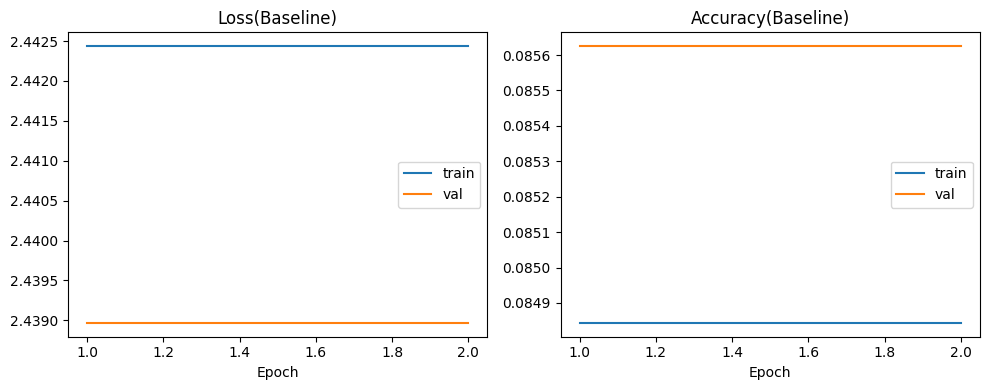

In [6]:
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')


## 3. Validation vs Test Accuracy (Required)
Evaluate on the held-out test set and overlay the test accuracy on the validation curve. Then write a short reflection (3–5 sentences) on the generalization gap.

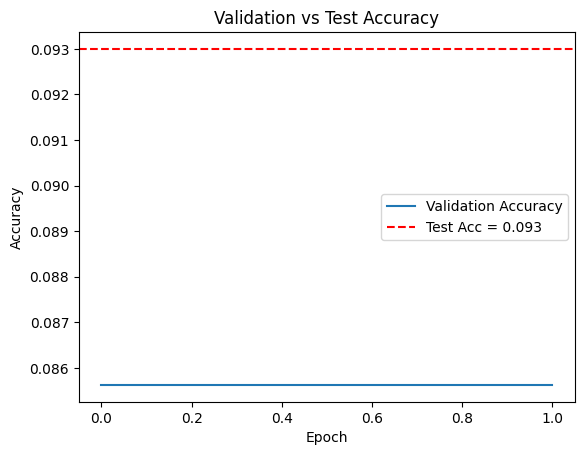

Final Test Accuracy: 0.0930


In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


### Reflection (Your text)
- <b>Explain the gap between validation and test accuracy.</b><br>

    The gap is... <br>

- <b>What might cause it, and what would you try next to reduce it? </b> <br>

    Possible causes could be <br> Overfitting <br> Different data distribution <br> Random data variation

- <b>How much of the dataset do you use for training, validation, and testing? Explain your answer with the % calculation.</b><br> 

    80% for both validation and training and 20% for testing <br> 

- <b>How many images are there in the original dataset?</b> <br>

    10000 <br> 

- <b>How big are the images? </b> <br>

    Images are 28x28 <br> 

- <b>What observations can you tell about the original data?</b> <br>

    What i can tell is, there are 10000, 28,28 shaped pictures. With 10 different labels which are from 0 to 9</b>  <br> 

- <b>What are possible labels for the images?</b> <br>

    Labels are 0 - 9 for each numbers </b> <br> 
    
- <b>What are the steps when making models?</b> <br>
1 - define the architecture, <br> 2 - compile the model, <br>3 - fit the model to the data.


## 4. Improved Model (Your work)
Build a better model, train it here as many times as you feel like and when you are pleased with it, title it `final_model`.  Report every try individually, not only the final version.

Explain every step with markdown text and code comments.   

Unrunnable code is not checked. 

Loaded data shapes: (10000, 28, 28) (10000,)



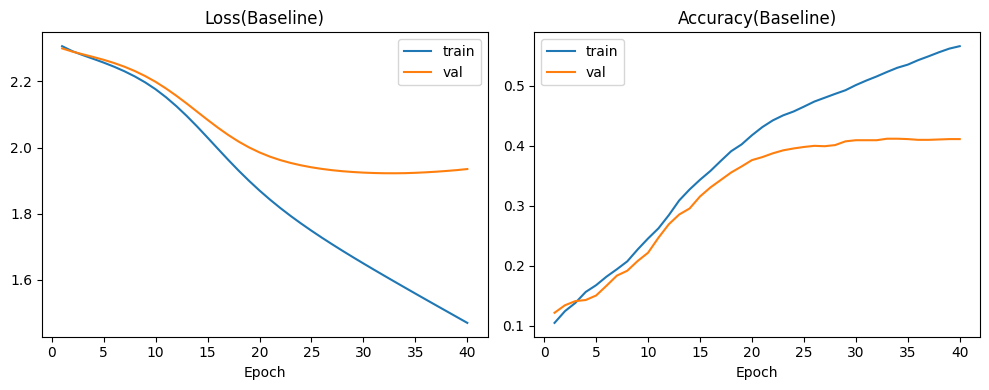

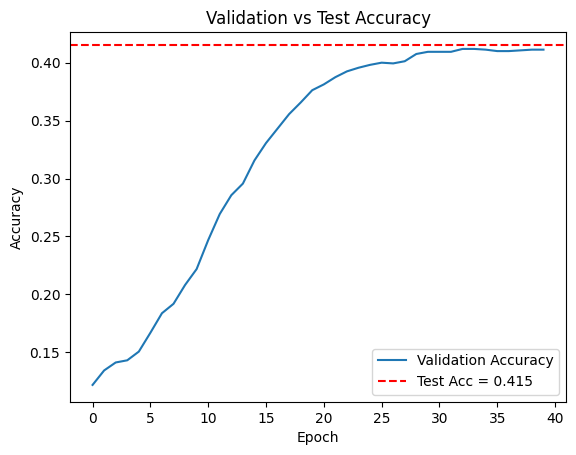

Final Test Accuracy: 0.4150


In [8]:
# 1) Imports & Reproducibility (Fixed)
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)  # random seed for reproducibility

with open('mnist.hupsista','rb') as f: # Expects a pickle file containing (X, y) as numpy arrays.
    X_all, y_all = pickle.load(f) 
    print('Loaded data shapes:', X_all.shape, y_all.shape) # Check data shapes after loading

X_all = X_all.astype('float32') # Convert to float32 for TensorFlow compatibility
if X_all.max() > 1.0:
    X_all /= 255.0  # Normalize to [0,1] for tensorflow
if X_all.ndim == 3:
    X_all = X_all[..., None] # Ensure channel dimension for CNN input

unique_labels = np.unique(y_all)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all 
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'), # Added hidden layer with 512 units 
    layers.Dense(256, activation='relu'), # Added hidden layer with 256 units
    layers.Dense(128, activation='relu'), # Added hidden layer with 128 units
    layers.Dense(64, activation='relu'),  # Added hidden layer with 64 units
    layers.Dense(10, activation='sigmoid'),
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate= 0.0025), # Reduced learning rate to 0.0025 for better convergence
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs= 40, validation_data=(X_val, y_val), verbose=0) # Increased epochs to 40 for better training

print()
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')
 


<b> Reflection </b><br>

<b> - Steps I took to increase the final test accuracy.</b> <br> First I added more hidden layers for better feature extraction. <br> Then tested changing the learning rate to various numbers then settled to 0.0025 for better convergence <br> Then increased the epoches to 40 for better training. 

Having a hard time with machine learning :(

-------
# **| Fixed Exam file starts from here |**
-------

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.1191 - loss: 2.3007 - val_accuracy: 0.1731 - val_loss: 2.2617
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.1736 - loss: 2.2195 - val_accuracy: 0.3381 - val_loss: 2.0547
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2639 - loss: 2.0813 - val_accuracy: 0.4038 - val_loss: 1.9064
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3294 - loss: 1.9309 - val_accuracy: 0.4725 - val_loss: 1.6825
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4025 - loss: 1.7542 - val_accuracy: 0.5113 - val_loss: 1.4867
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4378 - loss: 1.6251 - val_accuracy: 0.5219 - val_loss: 1.3842
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4775 - loss: 1.5208 - val_accuracy: 0.5250 - val_loss: 1.3158
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4981 - loss: 1.4480 - val_accu

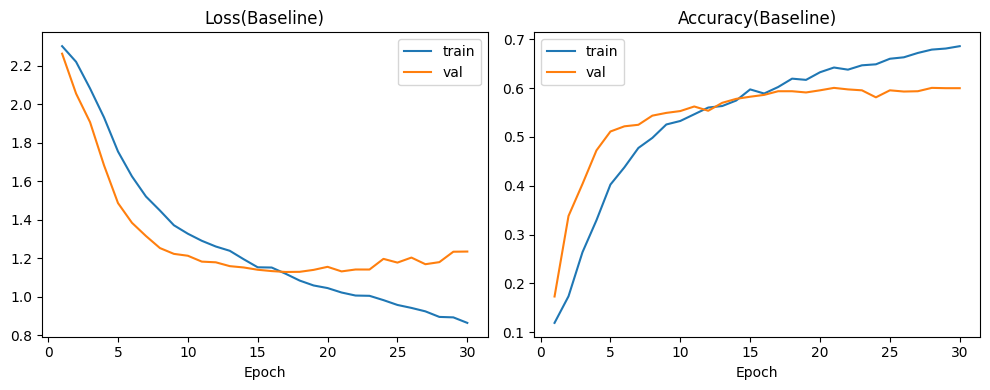

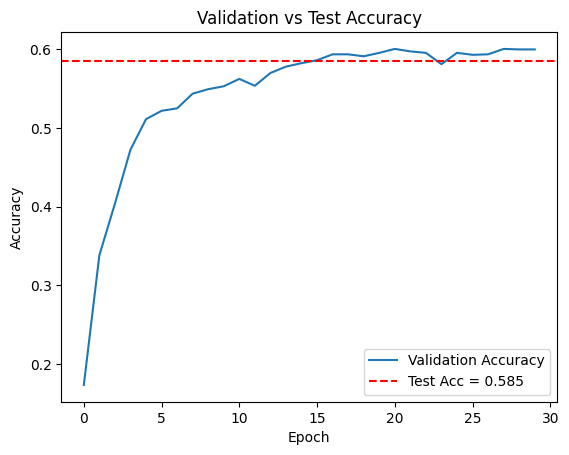

Final Test Accuracy: 0.5850


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,424 (5.38 MB)

 Trainable params: 470,474 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 940,950 (3.59 MB)

In [9]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),  # Added convolutional layer with 32 filters
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'), # Added hidden layer with 512 units
    layers.Dropout(0.5),  # Adding dropout layer for regularization and preventing overfitting
    layers.Dense(128, activation='relu'), # Added hidden layer with 128 units
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),  # Added hidden layer with 64 units
    layers.Dropout(0.6),
    layers.Dense(10, activation='softmax'), # Changed activation to softmax for multi-class classification'),
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=True)

history = model.fit(X_train, y_train, epochs= 30, validation_data=(X_val, y_val), batch_size=64, verbose=1) # Increased epochs to 30 for better training

print()
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')
model.summary()

#### Added Convulation layer and dropout rate layers. got ideas from the exam model. This is the highest i got yet, next going to try to play more with layers to see if i can get more acuracy. Changing epoch, adding more hidden layers, changing dropout rate etc. and also try to reduce total param maybe



well i had no luck :(


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.2284 - loss: 2.1461 - val_accuracy: 0.1419 - val_loss: 2.3330
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.4173 - loss: 1.7379 - val_accuracy: 0.1044 - val_loss: 2.3227
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.4750 - loss: 1.5276 - val_accuracy: 0.1531 - val_loss: 2.3950
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.5063 - loss: 1.4202 - val_accuracy: 0.1894 - val_loss: 2.1813
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.5273 - loss: 1.3528 - val_accuracy: 0.3581 - val_loss: 1.7519
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.5447 - loss: 1.2881 - val_accuracy: 0.5175 - val_loss: 1.4719
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.5456 - loss: 1.2544 - val_accuracy: 0.5606 - val_loss: 1.2085
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.5614 - loss: 1.2125 - val_accu

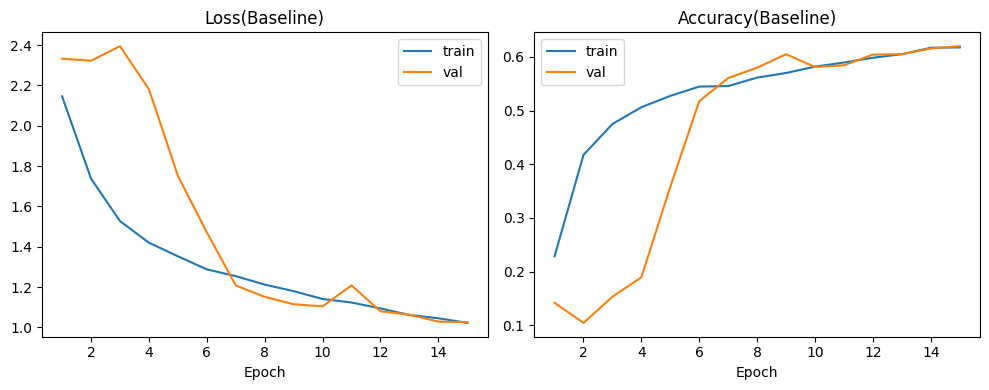

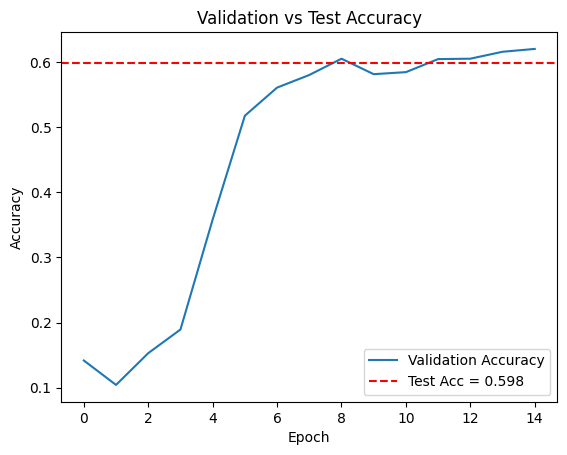

Final Test Accuracy: 0.5980


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 445,056 (1.70 MB)

 Trainable params: 148,202 (578.91 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 296,406 (1.13 MB)

In [10]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    # layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),  # Added convolutional layer with 32 filters
    # layers.MaxPooling2D(pool_size=(2, 2)),
    # layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    # layers.MaxPooling2D(pool_size=(2, 2)),
    # layers.Flatten(),
    # layers.Dense(256, activation='relu'), # Added hidden layer with 512 units
    # layers.Dropout(0.5),  # Adding dropout layer for regularization and preventing overfitting
    # layers.Dense(128, activation='relu'), # Added hidden layer with 128 units
    # layers.Dropout(0.5),
    # layers.Dense(64, activation='relu'),  # Added hidden layer with 64 units
    # layers.Dropout(0.6),
    # layers.Dense(10, activation='softmax'), # Changed activation to softmax for multi-class classification'),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128,3,padding='same',activation='relu'),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=True)

history = model.fit(X_train, y_train, epochs= 15, validation_data=(X_val, y_val), batch_size=64, verbose=1) # Increased epochs to 30 for better training

print()
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')
model.summary()






Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.2427 - loss: 2.1291 - val_accuracy: 0.1206 - val_loss: 2.2764
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.4042 - loss: 1.7527 - val_accuracy: 0.0812 - val_loss: 2.6001
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.4780 - loss: 1.5174 - val_accuracy: 0.1238 - val_loss: 2.5976
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.5120 - loss: 1.4008 - val_accuracy: 0.1900 - val_loss: 2.3555
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.5294 - loss: 1.3217 - val_accuracy: 0.3769 - val_loss: 1.8742
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.5414 - loss: 1.2687 - val_accuracy: 0.5550 - val_loss: 1.2358
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.5633 - loss: 1.2199 - val_accuracy: 0.5350 - val_loss: 1.2414
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.5750 - loss: 1.1887 - val_accu

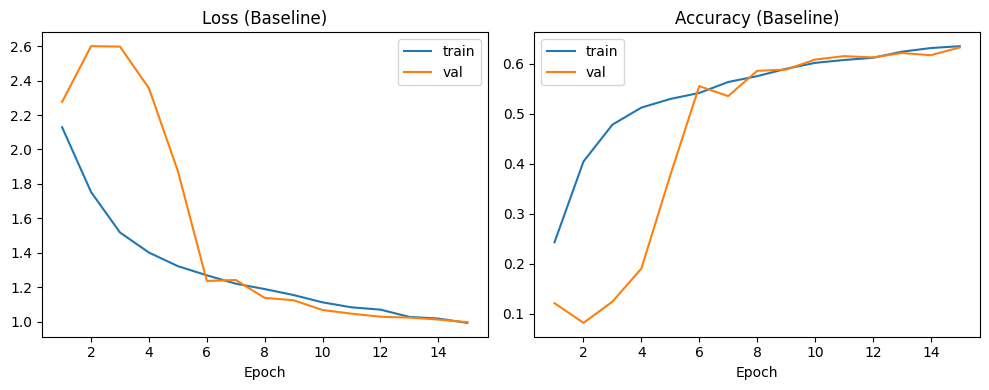

Final Test Accuracy: 0.6100
Correct Predictions: 1220
Reward: €122000
Total Model Parameters: 148650
Net Score: €-26650


In [11]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=True
)

# --- Train the model ---
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_val, y_val),
    batch_size=64,
    verbose=1
)

# --- Plot training curves ---
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss {title_suffix}'); plt.xlabel('Epoch'); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy {title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout()
    plt.show()

plot_curves(history, '(Baseline)')

# --- Evaluate on test set ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Final Test Accuracy: {test_acc:.4f}')

# --- Custom Reward / Penalty Scoring Function ---
def evaluate_model_score(model, x_test, y_test):
    """
    Evaluate a Keras model and calculate reward minus total params.
    """
    # Predict class labels
    predictions = np.argmax(model.predict(x_test, verbose=0), axis=1)
    
    # Count correct predictions
    correct_predictions = np.sum(predictions == y_test)
    
    # Reward calculation
    reward = (
        min(correct_predictions, 5000) * 100 +
        min(max(correct_predictions - 5000, 0), 1000) * 200 +
        max(correct_predictions - 6000, 0) * 1000
    )
    
    # Model size penalty
    total_params = model.count_params()
    
    net_score = reward - total_params
    return net_score, reward, total_params, correct_predictions

# --- Apply custom score ---
net_score, reward, total_params, correct_predictions = evaluate_model_score(model, X_test, y_test)

print(f"Correct Predictions: {correct_predictions}")
print(f"Reward: €{reward}")
print(f"Total Model Parameters: {total_params}")
print(f"Net Score: €{net_score}")